In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Date Alignment

In [5]:
raw_analyst_df=pd.read_csv('../data/raw/raw_analyst_ratings.csv')

In [4]:
folder_path = "../data/raw/yfinance_data"  # folder containing CSVs

dfs = []

# Loop through all CSV files in the folder
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)
        dfs.append(df)

# Combine all CSVs into one DataFrame
yfinance_df = pd.concat(dfs, ignore_index=True)

In [13]:
# Normalize date columns
# Make all columns lowercase
yfinance_df.columns = yfinance_df.columns.str.lower()
raw_analyst_df.columns = raw_analyst_df.columns.str.lower()

# Now convert the date column
yfinance_df['date'] = pd.to_datetime(yfinance_df['date'], errors='coerce').dt.date
raw_analyst_df['date'] = pd.to_datetime(raw_analyst_df['date'], errors='coerce').dt.date


In [14]:
# Date Alignment
# Merge datasets on date
df = pd.merge(raw_analyst_df, yfinance_df, on='date', how='inner')

## Sentiment Analysis

In [15]:
from textblob import TextBlob

# Function to calculate sentiment polarity
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Apply sentiment analysis
df['sentiment'] = df['headline'].apply(get_sentiment)

# Aggregate sentiment by date
daily_sentiment = df.groupby('date')['sentiment'].mean().reset_index()


## Calculate Daily Stock Returns

In [18]:
yfinance_df['daily_return'] = yfinance_df['close'].pct_change()  # Returns in decimal
yfinance_df['daily_return'] = yfinance_df['daily_return'].fillna(0)

analysis_df = pd.merge(daily_sentiment, yfinance_df[['date', 'daily_return']], on='date')


## Correlation Analysis

In [19]:
correlation = analysis_df['sentiment'].corr(analysis_df['daily_return'])
print(f"Correlation between news sentiment and stock returns: {correlation:.4f}")


Correlation between news sentiment and stock returns: 0.0055


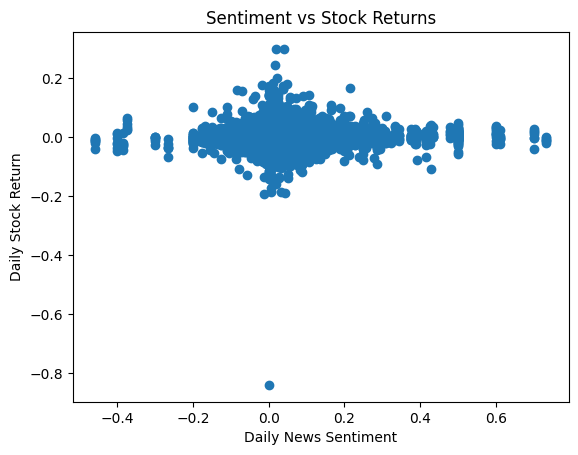

In [20]:
import matplotlib.pyplot as plt

plt.scatter(analysis_df['sentiment'], analysis_df['daily_return'])
plt.xlabel('Daily News Sentiment')
plt.ylabel('Daily Stock Return')
plt.title('Sentiment vs Stock Returns')
plt.show()
